Test 2 : Using Linear Regression

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/final.csv")

In [3]:
df = df.drop(columns=['_id_x', '_id_y'])

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

In [4]:
df['hour'] = df.index.hour


In [5]:
df = df.dropna()

In [6]:
train = df[:'2024']
test = df['2025':]

X_train = train.drop(columns=['wdLoad'])
y_train = train['wdLoad']

X_test = test.drop(columns=['wdLoad'])
y_test = test['wdLoad']

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np
preds = model.predict(X_test)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 132.56805745063355


In [9]:
df.head()

,wdLoad,temp,rh,hour
datetime,,,,
2017-12-31 18:30:00+00:00,227.02,19.12,68.06,18
2017-12-31 18:45:00+00:00,226.78,19.06,68.14,18
2017-12-31 19:00:00+00:00,225.58,18.96,68.32,19
2017-12-31 19:15:00+00:00,224.05,18.97,66.54,19
2017-12-31 19:30:00+00:00,222.34,18.90,67.32,19


In [13]:
import shap

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test)

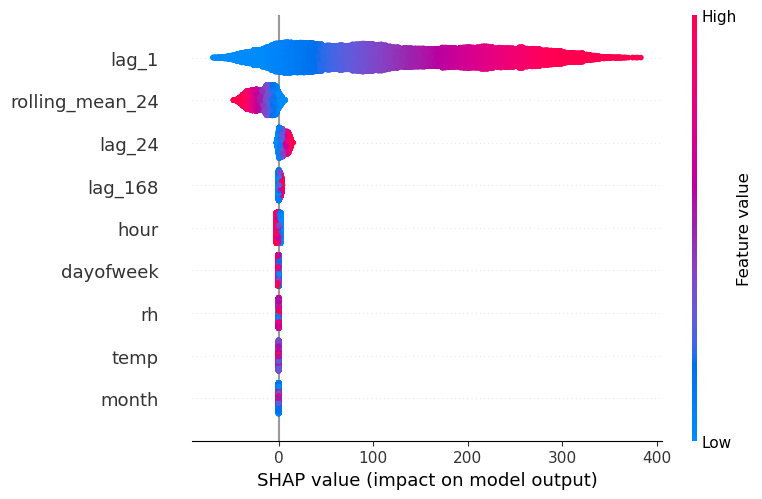

In [14]:
shap.summary_plot(shap_values, X_test)

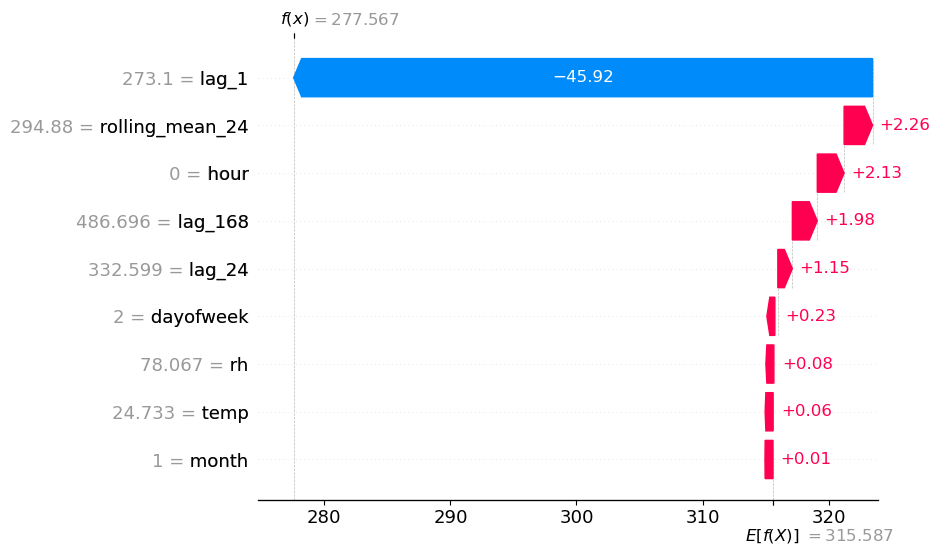

In [15]:
shap.plots.waterfall(shap_values[0])

In [21]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    mode='regression'
)

exp = explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict
)

exp.show_in_notebook()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ImportError: cannot import name 'display' from 'IPython.core.display' (/opt/anaconda3/lib/python3.12/site-packages/IPython/core/display.py)

In [10]:
import pandas as pd

coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coeff_df.sort_values(by='Coefficient', ascending=False))

  Feature  Coefficient
0    temp    12.858532
1      rh    -0.067857
2    hour    -2.840464


In [18]:
exp = explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict
)

print(exp.as_list())

[('243.39 < lag_1 <= 300.58', -64.61598606121137), ('248.81 < rolling_mean_24 <= 302.76', 9.037906721409596), ('300.59 < lag_24 <= 375.93', -7.330614899694083), ('hour <= 6.00', 5.586514555213887), ('1.00 < dayofweek <= 3.00', 3.1010697570198387), ('73.00 < rh <= 83.52', 2.2532583731415405), ('lag_168 > 375.77', 1.9642955931718826), ('temp <= 26.00', -0.6851259449732751), ('month <= 4.00', 0.44411830921263734)]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
